En este trabajo se estudia el problema de contorno dado por:
		$$\frac{1}{\alpha} \frac{\partial T(x,t)}{\partial t}=\frac{\partial^2 T(x,t)}{\partial x^2}-\sigma^2 \left((T(x,t)\right) T(x,t)+f(x) \ , \ 0<x<L \ , \ 0<t<t_{max}$$
		$$\frac{\partial T(0,t)}{\partial x}=\beta T(0)-\gamma $$
		$$T(L,t)=\delta \ , \ 0<t<t_{max} $$
		$$f(x)=F_0 e^{-\mu x} \ , \ 0<t<t_{max}$$
La parte espacial se discretiza mediante diferencias finitas de segundo orden. La condició de Robin se discretiza con la ayuda del nodo fantasma. La integración temporal se realiza mediante el métod de Crank-Nicolson, con aproximaciones sucesivas por el método de Picard.

La condición inicial es $$T(x,0)=g(x)=\frac{x}{L}$$

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


 INICIANDO INTEGRACIÓN TEMPORAL (CRANK-NICOLSON + PICARD) 
¡Simulación temporal completada con éxito!


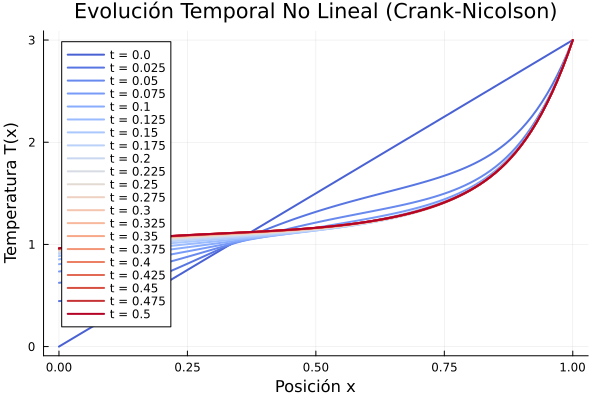

In [4]:
# ==========================================
# PREPARACIÓN DEL ENTORNO
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

using LinearAlgebra
using Plots

function simular_transitorio_picard_interno()
    # =================================================================
    # 1. PARÁMETROS GEOMÉTRICOS, FRONTERAS Y PARAMETRIZACIÓN NO LINEAL
    # =================================================================
    L, β, γ, δ = 1.0, 1.5, 0.5, 3.0
    F0, μ = 10.0, 1.0
    
    # Parámetro alfa (difusividad térmica / acoplamiento)
    alpha = 0.5 
    
    σ2_min, σ2_max = 2.0^2, 6.0^2  
    Tc, k_sig = 1.6, 5.0     
    calcular_σ2(T) = σ2_min + (σ2_max - σ2_min) / (1.0 + exp(-k_sig * (T - Tc)))

    N = 100
    dx = L / N
    x_nodos = collect(0:dx:L)
    f(x) = F0 * exp(-μ * x)

    t_final = 0.5
    dt = 0.005
    pasos_tiempo = round(Int, t_final / dt)

    ω_relajacion = 0.3  
    tol_picard = 1e-5
    max_iter_picard = 20

    T_actual = [ (i-1)*dx * (δ/L) for i in 1:N ]
    historial_T = [copy([T_actual; δ])]
    tiempos_guardados = [0.0]

    println("="^60)
    println(" INICIANDO INTEGRACIÓN TEMPORAL (CRANK-NICOLSON + PICARD) ")
    println("="^60)

    function construir_operador_espacial(T_estado)
        σ2_local = calcular_σ2.(T_estado)
        
        dv = zeros(N)
        ev = zeros(N - 1)
        b = zeros(N)

        dv[1] = -(1/dx^2 + β/dx + σ2_local[1]/2)
        ev[1] = 1/dx^2
        b[1] = -f(0)/2 - γ/dx

        for i in 2:N-1
            dv[i] = -(2/dx^2 + σ2_local[i])
            ev[i] = 1/dx^2
            b[i] = -f((i-1)*dx)
        end

        dv[N] = -(2/dx^2 + σ2_local[N])
        b[N] = -f((N-1)*dx) - (1/dx^2) * δ

        return SymTridiagonal(dv, ev), b
    end

    Id = diagm(0 => ones(N))

    for t_paso in 1:pasos_tiempo
        t_actual_eval = t_paso * dt
        A_n, b_n = construir_operador_espacial(T_actual)

        T_futuro_actual = copy(T_actual)
        T_futuro_nuevo = zeros(N)
        
        picard_iter = 0
        convergido_picard = false

        while !convergido_picard && picard_iter < max_iter_picard
            picard_iter += 1
            A_np1, b_np1 = construir_operador_espacial(T_futuro_actual)

            # ==============================================================
            # PROPAGACIÓN DE ALFA EN LOS ESQUEMAS TEMPORALES
            # ==============================================================
            if t_paso <= 2
                # Euler Implícito: (Id - alpha*dt*A_np1)*T = T_n - alpha*dt*b_np1
                M_izq = Id - (alpha * dt) * A_np1
                RHS = T_actual - (alpha * dt) * b_np1
            else
                # Crank-Nicolson: (Id - alpha*dt/2 * A_np1)*T = (Id + alpha*dt/2 * A_n)*T_n - alpha*dt/2 * (b_n + b_np1)
                coeff_cn = alpha * dt / 2.0
                M_izq = Id - coeff_cn * A_np1
                RHS = (Id + coeff_cn * A_n) * T_actual - coeff_cn * (b_n + b_np1)
            end

            T_calc = M_izq \ RHS
            T_futuro_nuevo = ω_relajacion .* T_calc .+ (1.0 - ω_relajacion) .* T_futuro_actual

            if norm(T_futuro_nuevo - T_futuro_actual, Inf) < tol_picard
                convergido_picard = true
            else
                T_futuro_actual = copy(T_futuro_nuevo)
            end
        end

        T_actual = copy(T_futuro_nuevo)

        if t_paso % 5 == 0 || t_paso == pasos_tiempo
            push!(historial_T, [T_actual; δ])
            push!(tiempos_guardados, t_actual_eval)
        end
    end

    println("¡Simulación temporal completada con éxito!")

    p = plot(grid=true, title="Evolución Temporal No Lineal (Crank-Nicolson)", 
             xlabel="Posición x", ylabel="Temperatura T(x)", legend=:topleft)
    
    for (idx, T_perfil) in enumerate(historial_T)
        t_lbl = tiempos_guardados[idx]
        col = cgrad(:coolwarm)[idx / length(historial_T)]
        plot!(p, x_nodos, T_perfil, lw=2, color=col, label="t = $(round(t_lbl, digits=3))")
    end
    
    display(p)
end

simular_transitorio_picard_interno()